In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score
import seaborn as sns
import matplotlib.pyplot as plt
import phik 
from phik.report import plot_correlation_matrix
import plotly.express as px
import xgboost as xgb
import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold

In [2]:
dataset_train_path = '/kaggle/input/competitions/scooter-price-prediction-edu-2026/train.csv'
dataset_train = pd.read_csv(dataset_train_path)
dataset_train

,id,trip_duration_min,distance_km,battery_level_start,temperature_c,wind_speed,demand_index,distance_km_noisy,city_zone,scooter_model,is_weekend,rental_price,avg_price_last_week,route_complexity,driver_experience,weather_rating
0,0,25.599707,7.441135,78.519717,6.128784,8.680982,0.861114,11.102968,center,C,0,16.238355,4.985755,-0.777649,6.163800,3
1,1,57.289287,8.770495,NaN,15.947497,8.812507,0.078338,9.426186,park,A,1,6.231436,3.751414,1.587773,2.568192,3
2,2,45.259667,6.147492,31.714901,26.099837,3.501865,0.072575,6.285575,center,A,0,8.914843,2.666093,2.251650,5.311526,1
3,3,37.926217,7.740660,86.634377,11.560209,NaN,0.850318,8.455020,park,B,1,11.197729,5.835958,0.567339,9.418034,2
4,4,13.581025,3.846835,63.223723,15.542815,7.245579,0.212850,7.641726,suburb,B,0,0.560182,0.058212,1.688476,5.726172,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,1195,52.934524,12.453208,29.536835,16.305378,NaN,0.188059,15.834265,park,A,0,7.444761,2.307741,NaN,5.292383,3
1196,1196,58.541893,10.690922,22.916884,8.569641,1.093559,0.428019,10.387413,park,C,0,6.159082,1.081612,NaN,7.050770,1
1197,1197,58.288282,9.855832,24.219516,NaN,3.972913,0.658284,9.580964,center,C,0,16.640635,8.839463,0.579458,8.462460,5
1198,1198,46.230851,12.539495,86.733129,28.792560,3.368477,0.263806,10.376629,center,A,0,10.474559,3.757816,0.013809,2.354944,4


In [3]:
dataset_test_path = '/kaggle/input/competitions/scooter-price-prediction-edu-2026/test.csv'
dataset_test = pd.read_csv(dataset_test_path)
dataset_test

,id,trip_duration_min,distance_km,battery_level_start,temperature_c,wind_speed,demand_index,distance_km_noisy,city_zone,scooter_model,is_weekend,avg_price_last_week,route_complexity,driver_experience,weather_rating
0,0,11.328001,2.984336,55.779495,8.091798,4.066090,0.663601,1.963757,center,B,0,5.806129,1.306705,2.784195,4
1,1,38.498660,11.646348,82.460577,14.587610,0.324484,0.025097,10.144005,suburb,B,0,5.436778,-0.557203,5.089479,2
2,2,12.336503,3.903070,27.184917,26.280163,0.803103,0.550207,0.263852,park,A,1,4.894052,1.443238,3.010447,1
3,3,18.232429,5.046844,25.686523,NaN,9.745415,0.365754,7.439801,center,B,0,1.831494,-0.327021,7.365486,4
4,4,22.992648,8.149461,39.617766,9.642400,4.688548,0.991382,6.484963,suburb,B,0,2.108906,0.838731,7.793396,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,43.112225,8.978582,82.923541,5.654423,9.370275,0.459456,8.991758,center,B,1,-3.018228,0.883837,4.896130,5
396,396,25.608918,8.323399,NaN,20.737456,NaN,0.764556,7.836870,center,C,1,6.586721,-0.114967,7.298412,1
397,397,14.697977,2.685677,67.029584,NaN,5.526136,0.624240,2.637048,center,B,1,4.023122,-0.519887,2.167444,2
398,398,14.387681,2.809646,78.200071,17.991054,7.907391,0.723451,3.841310,suburb,A,0,1.839318,-0.421520,0.093065,2


In [13]:
dataset_test_copy = dataset_test
test_ids = dataset_test_copy['id'].copy()

In [11]:
dataset_train_copy = dataset_train

interval columns not set, guessing: ['id', 'trip_duration_min', 'distance_km', 'battery_level_start', 'temperature_c', 'wind_speed', 'demand_index', 'distance_km_noisy', 'is_weekend', 'rental_price', 'avg_price_last_week', 'route_complexity', 'driver_experience', 'weather_rating']


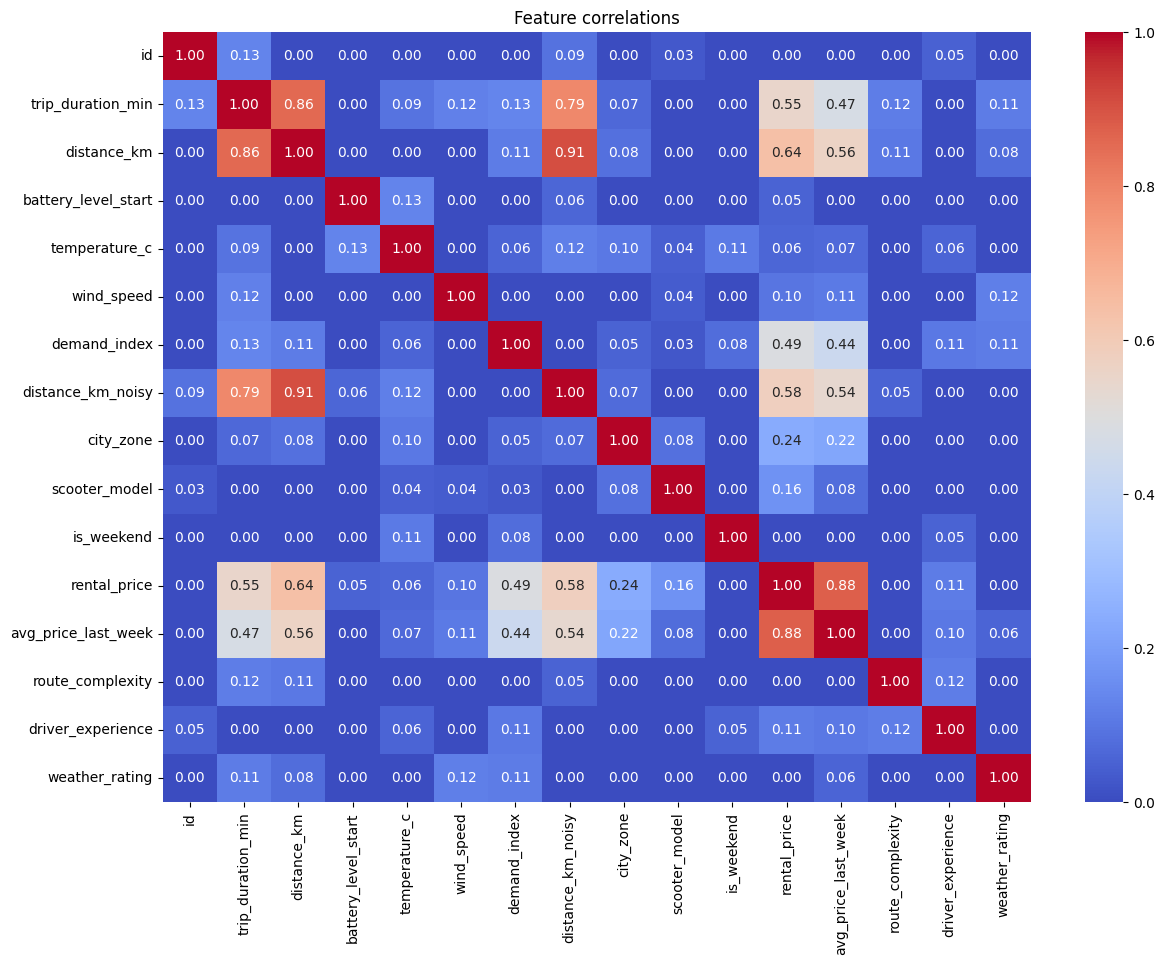

In [5]:
phik_matrix = dataset_train_copy.phik_matrix()
plt.figure(figsize=(14, 10))

sns.heatmap(phik_matrix, 
           annot=True,
           cmap='coolwarm',
           fmt='.2f',
            vmin=0, vmax=1)

plt.title('Feature correlations')
plt.show()

In [6]:
dataset_train_copy.isna().any()

id                     False
trip_duration_min      False
distance_km            False
battery_level_start     True
temperature_c           True
wind_speed              True
demand_index           False
distance_km_noisy      False
city_zone              False
scooter_model          False
is_weekend             False
rental_price           False
avg_price_last_week    False
route_complexity        True
driver_experience      False
weather_rating         False
dtype: bool

In [7]:
def count_outliers_iqr(column):
    q1 = column.quantile(0.25)
    q3 = column.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return ((column < lower_bound) | (column > upper_bound)).sum()

In [8]:
numeric_dataset = dataset_train_copy.select_dtypes(include=['number'])
outliers_count = numeric_dataset.apply(count_outliers_iqr)

columns_with_outliers = outliers_count[outliers_count > 0].sort_values(ascending=False)
print(columns_with_outliers.head(10))

rental_price           45
avg_price_last_week    27
route_complexity        6
distance_km_noisy       4
dtype: int64


In [9]:
numeric_features = [
    'trip_duration_min',
    'distance_km',
    'battery_level_start',
    'temperature_c',
    'wind_speed',
    'demand_index',
    'distance_km_noisy',
    'is_weekend',
    'rental_price',
    'avg_price_last_week',
    'route_complexity',
    'driver_experience',
    'weather_rating'
]
categoric_features = ['city_zone', 'scooter_model']

In [14]:
for column in categoric_features:
    dataset_train_copy[column] = dataset_train_copy[column].astype('category')
    dataset_test_copy[column] = dataset_test_copy[column].astype('category')

In [26]:
y = dataset_train_copy['rental_price']
dataset_train_copy = dataset_train_copy.drop(['id', 'distance_km', 'rental_price'], axis=1)

KeyError: 'rental_price'

In [16]:
y_log = np.log1p(y)

In [28]:
dataset_test_copy = dataset_test_copy.drop(['id', 'distance_km'], axis=1)

In [17]:
dataset_train_copy['speed'] = dataset_train_copy['distance_km_noisy'] / (dataset_train_copy['trip_duration_min'] / 60)
dataset_train_copy['zone_avg_price'] = dataset_train_copy.groupby('city_zone')['avg_price_last_week'].transform('mean')
dataset_train_copy['scooter_avg_speed'] = dataset_train_copy.groupby('scooter_model')['speed'].transform('mean')
dataset_train_copy['demand_weather_ratio'] = dataset_train_copy['demand_index'] / (dataset_train_copy['weather_rating'] + 1)
dataset_train_copy['distance_per_battery'] = dataset_train_copy['distance_km_noisy'] / (dataset_train_copy['battery_level_start'] + 0.1)
dataset_train_copy['driver_risk_index'] = dataset_train_copy['route_complexity'] / (dataset_train_copy['driver_experience'] + 0.1)

/tmp/ipykernel_55/2448029608.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dataset_train_copy['zone_avg_price'] = dataset_train_copy.groupby('city_zone')['avg_price_last_week'].transform('mean')
/tmp/ipykernel_55/2448029608.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dataset_train_copy['scooter_avg_speed'] = dataset_train_copy.groupby('scooter_model')['speed'].transform('mean')


In [18]:
dataset_test_copy['speed'] = dataset_test_copy['distance_km_noisy'] / (dataset_test_copy['trip_duration_min'] / 60)
dataset_test_copy['zone_avg_price'] = dataset_test_copy.groupby('city_zone')['avg_price_last_week'].transform('mean')
dataset_test_copy['scooter_avg_speed'] = dataset_test_copy.groupby('scooter_model')['speed'].transform('mean')
dataset_test_copy['demand_weather_ratio'] = dataset_test_copy['demand_index'] / (dataset_test_copy['weather_rating'] + 1)
dataset_test_copy['distance_per_battery'] = dataset_test_copy['distance_km_noisy'] / (dataset_test_copy['battery_level_start'] + 0.1)
dataset_test_copy['driver_risk_index'] = dataset_test_copy['route_complexity'] / (dataset_test_copy['driver_experience'] + 0.1)

/tmp/ipykernel_55/2566410668.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dataset_test_copy['zone_avg_price'] = dataset_test_copy.groupby('city_zone')['avg_price_last_week'].transform('mean')
/tmp/ipykernel_55/2566410668.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dataset_test_copy['scooter_avg_speed'] = dataset_test_copy.groupby('scooter_model')['speed'].transform('mean')


In [19]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0),
        'random_seed': 42,
        'verbose': False
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []
    X_reset = dataset_train_copy.reset_index(drop=True)
    y_reset = y.reset_index(drop=True)

    for train_index, validation_index in kf.split(X_reset):
        X_fold_train, X_fold_validation = X_reset.iloc[train_index], X_reset.iloc[validation_index]
        y_fold_train, y_fold_validation = y_reset.iloc[train_index], y_reset.iloc[validation_index]

        model = CatBoostRegressor(**params)
        model.fit(X_fold_train, np.log1p(y_fold_train), cat_features=categoric_features)

        predictions = model.predict(X_fold_validation)
        real_predictions = np.expm1(predictions)
        r2 = r2_score(y_fold_validation, real_predictions)
        fold_scores.append(r2)

    return np.mean(fold_scores)

In [20]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f'Best R2 score: {study.best_value:.6f}')
print(f'Best params: {study.best_params}')

[I 2026-04-18 12:08:08,747] A new study created in memory with name: no-name-f9d48f5b-1377-4afd-a7e7-d944faaa493c
[I 2026-04-18 12:08:16,370] Trial 0 finished with value: 0.8170837192465077 and parameters: {'iterations': 610, 'learning_rate': 0.12582127803493273, 'depth': 6, 'l2_leaf_reg': 6.748708092104688}. Best is trial 0 with value: 0.8170837192465077.
[I 2026-04-18 12:08:36,630] Trial 1 finished with value: 0.8001435649299973 and parameters: {'iterations': 262, 'learning_rate': 0.07739979136623401, 'depth': 10, 'l2_leaf_reg': 2.8224457204274094}. Best is trial 0 with value: 0.8170837192465077.
[I 2026-04-18 12:08:39,955] Trial 2 finished with value: 0.8138651536026545 and parameters: {'iterations': 366, 'learning_rate': 0.19410730430531098, 'depth': 5, 'l2_leaf_reg': 3.0748183690509228}. Best is trial 0 with value: 0.8170837192465077.
[I 2026-04-18 12:08:48,586] Trial 3 finished with value: 0.8014293405428198 and parameters: {'iterations': 426, 'learning_rate': 0.17986840584435307

Best R2 score: 0.841150
Best params: {'iterations': 998, 'learning_rate': 0.011096467434644664, 'depth': 4, 'l2_leaf_reg': 1.8253605173444751}


In [21]:
catboost_best_params = {
    'iterations': 998,
    'learning_rate': 0.011096467434644664,
    'depth': 4,
    'l2_leaf_reg': 1.8253605173444751,
    'random_seed': 42,
    'verbose': False
}

In [22]:
def objective_2(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'tree_method': 'hist', 
        'enable_categorical': True,
        'random_state': 42
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []
    X_reset = dataset_train_copy.reset_index(drop=True)
    y_reset = y.reset_index(drop=True)

    for train_index, validation_index in kf.split(X_reset):
        X_fold_train, X_fold_validation = X_reset.iloc[train_index], X_reset.iloc[validation_index]
        y_fold_train, y_fold_validation = y_reset.iloc[train_index], y_reset.iloc[validation_index]

        model = xgb.XGBRegressor(**params)
        model.fit(X_fold_train, np.log1p(y_fold_train))

        predictions = model.predict(X_fold_validation)
        real_predictions = np.expm1(predictions)
        r2 = r2_score(y_fold_validation, real_predictions)
        fold_scores.append(r2)

    return np.mean(fold_scores)

In [23]:
study_2 = optuna.create_study(direction='maximize')
study_2.optimize(objective_2, n_trials=50)

print(f'Best R2 score: {study_2.best_value:.6f}')
print(f'Best params: {study_2.best_params}')

[I 2026-04-18 12:15:28,599] A new study created in memory with name: no-name-c226553c-52b7-45ae-a2b0-3d3ed806eb24
[I 2026-04-18 12:15:33,172] Trial 0 finished with value: 0.7955467561374087 and parameters: {'n_estimators': 156, 'learning_rate': 0.014692693537041878, 'max_depth': 8, 'reg_lambda': 0.026929381559402717, 'subsample': 0.9128317991460329, 'colsample_bytree': 0.868074908728742}. Best is trial 0 with value: 0.7955467561374087.
[I 2026-04-18 12:16:01,671] Trial 1 finished with value: 0.8262791843367963 and parameters: {'n_estimators': 813, 'learning_rate': 0.01645262975689105, 'max_depth': 10, 'reg_lambda': 0.0016416483887186184, 'subsample': 0.6071926579960953, 'colsample_bytree': 0.8433354209605192}. Best is trial 1 with value: 0.8262791843367963.
[I 2026-04-18 12:16:08,764] Trial 2 finished with value: 0.8088808347501446 and parameters: {'n_estimators': 601, 'learning_rate': 0.08406208298998061, 'max_depth': 9, 'reg_lambda': 0.03484989407330444, 'subsample': 0.63871286115733

Best R2 score: 0.843247
Best params: {'n_estimators': 209, 'learning_rate': 0.03814900855518942, 'max_depth': 4, 'reg_lambda': 0.2008314735287805, 'subsample': 0.7512757818029084, 'colsample_bytree': 0.6407074981236066}


In [24]:
xgb_best_params = {
    'n_estimators': 209,
    'learning_rate': 0.03814900855518942,
    'max_depth': 4,
    'reg_lambda': 0.2008314735287805,
    'subsample': 0.7512757818029084,
    'colsample_bytree': 0.6407074981236066,
    'tree_method': 'hist', 
    'enable_categorical': True,
    'random_state': 42
}

In [29]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
xgb_predictions = []
cat_predictions = []
oof_predictions = np.zeros(len(dataset_train_copy))

for fold, (train_index, validation_index) in enumerate(kf.split(dataset_train_copy)):
    X_train, X_validation = dataset_train_copy.iloc[train_index], dataset_train_copy.iloc[validation_index]
    y_train, y_validation = y_log.iloc[train_index], y_log.iloc[validation_index]

    xgb_model = xgb.XGBRegressor(**xgb_best_params)
    xgb_model.fit(X_train, y_train)
    xgb_predictions.append(xgb_model.predict(dataset_test_copy))
    xgb_validation_prediction = xgb_model.predict(X_validation)

    catboost_model = CatBoostRegressor(**catboost_best_params)
    catboost_model.fit(X_train, y_train, cat_features=categoric_features)
    cat_predictions.append(catboost_model.predict(dataset_test_copy))
    catboost_validation_prediction = catboost_model.predict(X_validation)

    blended_validation_predictions = xgb_validation_prediction * 0.4 + catboost_validation_prediction * 0.6
    oof_predictions[validation_index] = blended_validation_predictions

In [30]:
final_r2_score = r2_score(y, np.expm1(oof_predictions))
print(final_r2_score)

0.8464057560229445


In [26]:
final_xgb_log = np.mean(xgb_predictions, axis=0)
final_catboost_log = np.mean(cat_predictions, axis=0)
blended_predictions = final_xgb_log * 0.4 + final_catboost_log * 0.6
final_predictions = np.expm1(blended_predictions)

In [27]:
submission_dataset = pd.DataFrame({
    'id': test_ids,
    'rental_price': final_predictions
})

submission_dataset.to_csv('kfold_submission.csv', index=False)
print(submission_dataset.head())

   id  rental_price
0   0      7.371623
1   1      8.283547
2   2      4.811562
3   3      4.192139
4   4      7.367419
